In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('Titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis =  1 , inplace = True)


In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# drop cols

In [6]:
def drop_col(df: pd.DataFrame, drop_columns : list[str]) -> pd.DataFrame :
    '''
    drop specific columns from df

    parameter
    --------
    df : pd.DataFrame
    columns : list[str]

    return
    ------
    pd.DataFrame

    '''
    return df.drop(columns= drop_columns)



In [7]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


# Check datatypes 


In [8]:
dtype = df.dtypes
n_unique = df.nunique()
pd.DataFrame({'Dtype :' : dtype, 'Num_unique' : n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype :,int64,int64,str,float64,int64,int64,float64,str,str
Num_unique,2,3,2,88,7,7,248,147,3


In [9]:
def get_chk_dtypes(df : pd.DataFrame) -> pd.DataFrame :
    return pd.DataFrame({'Dtype : ': df.dtypes , 'Num_unique': df.nunique()}).T

In [10]:
get_chk_dtypes(df)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype :,int64,int64,str,float64,int64,int64,float64,str,str
Num_unique,2,3,2,88,7,7,248,147,3


In [11]:
cols = ['Pclass', 'Survived', 'SibSp', 'Sex',
        'Parch']
df[cols] = df[cols].astype('category')
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,str,str


# Handle null values

In [12]:
null = df.isnull().sum()
ratio = null / df.shape[0]
pd.DataFrame({'Nulls_sum': null, 'Ratio ' : ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Nulls_sum,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
Ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [13]:
ratio

Survived    0.000000
Pclass      0.000000
Sex         0.000000
Age         0.198653
SibSp       0.000000
Parch       0.000000
Fare        0.000000
Cabin       0.771044
Embarked    0.002245
dtype: float64

In [14]:
df = df.dropna(subset = ['Embarked'])

In [15]:
df = df.drop('Cabin', axis = 1)

In [16]:
mean = df['Age'].mean()
print(mean)
median = df['Age'].median()
print('=' * 30)
print(median)

df['Age'] = df['Age'].fillna(median)

29.64209269662921
28.0


In [17]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


# Detect Outlier

In [18]:
# num_cols = df.select_dtypes('number').columns
num_cols = ['Age', 'Fare']
for col in num_cols :
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    # print(q1, q3, iqr, lower,upper)
    lower_outlier = df[df[col] < lower ][col].values
    upper_outlier = df[df[col] > upper ][col].values

    df[col] = df[col].replace(lower_outlier, lower)
    df[col] = df[col].replace(upper_outlier, upper)
    print(upper_outlier)

[58.  55.  66.  65.  59.  71.  70.5 55.5 61.  56.  58.  59.  62.  58.
 63.  65.  61.  60.  64.  65.  56.  63.  58.  55.  71.  64.  62.  62.
 60.  61.  57.  80.  56.  58.  70.  60.  60.  70.  57.  74.  56. ]
[ 71.2833 263.     146.5208  82.1708  76.7292  83.475   73.5    263.
  77.2875 247.5208  73.5     77.2875  79.2     66.6     69.55    69.55
 146.5208  69.55   113.275   76.2917  90.      83.475   90.      79.2
  86.5    512.3292  79.65   153.4625 135.6333  77.9583  78.85    91.0792
 151.55   247.5208 151.55   110.8833 108.9     83.1583 262.375  164.8667
 134.5     69.55   135.6333 153.4625 133.65    66.6    134.5    263.
  75.25    69.3    135.6333  82.1708 211.5    227.525   73.5    120.
 113.275   90.     120.     263.      81.8583  89.1042  91.0792  90.
  78.2667 151.55    86.5    108.9     93.5    221.7792 106.425   71.
 106.425  110.8833 227.525   79.65   110.8833  79.65    79.2     78.2667
 153.4625  77.9583  69.3     76.7292  73.5    113.275  133.65    73.5
 512.3292  76.7292

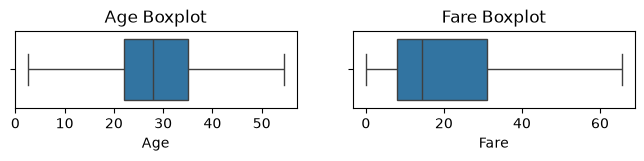

In [19]:
num_col = ['Age', 'Fare']
plt.figure(figsize = (8, 1))
for i , col in enumerate(num_col) :
    plt.subplot(1, 2 , i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} Boxplot')


In [20]:
def plot_num_boxploat(df : pd.DataFrame) :

    num_col = ['Age', 'Fare']
    plt.figure(figsize = (8, 1))

    for i , col in enumerate(num_col) :
        plt.subplot(1, 2 , i+1)
        sns.boxplot(df[col], orient='h')
        plt.title(f'{col} Boxplot')

    return plt.show()





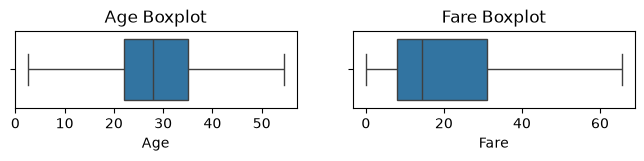

In [21]:
plot_num_boxploat(df)

In [22]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.000562,23.956061
std,12.051609,20.414997
min,2.500000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,54.500000,65.656300


In [23]:
df.duplicated().sum()

np.int64(129)

In [24]:
df = df.drop_duplicates()

In [25]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = 'first') :

    count = df.duplicated().sum
    print(count)

    return (df.drop_duplicates(subset=subset_cols, keep = keep_strategy).reset_index(drop = True)).head()

In [26]:
num_col

['Age', 'Fare']

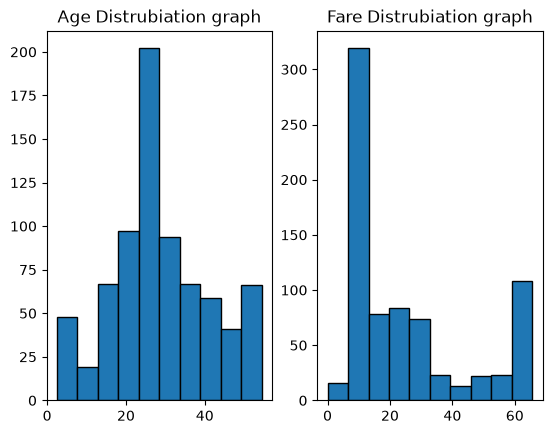

In [27]:
plt.Figure(figsize=(9,2))
for i , col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = 'Black')
    plt.title(f'{col} Distrubiation graph')

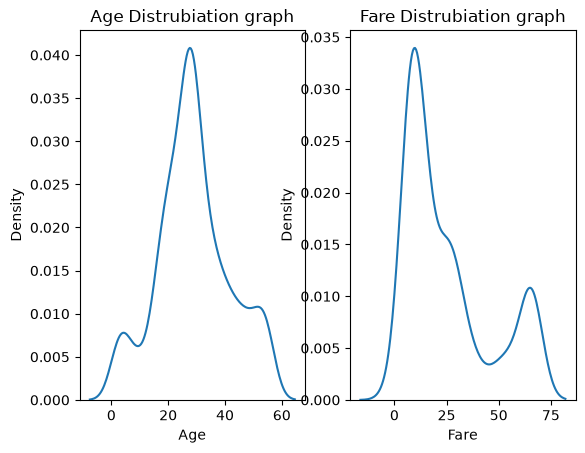

In [28]:
plt.Figure(figsize=(9,2))
for i , col in enumerate(num_col):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f'{col} Distrubiation graph')

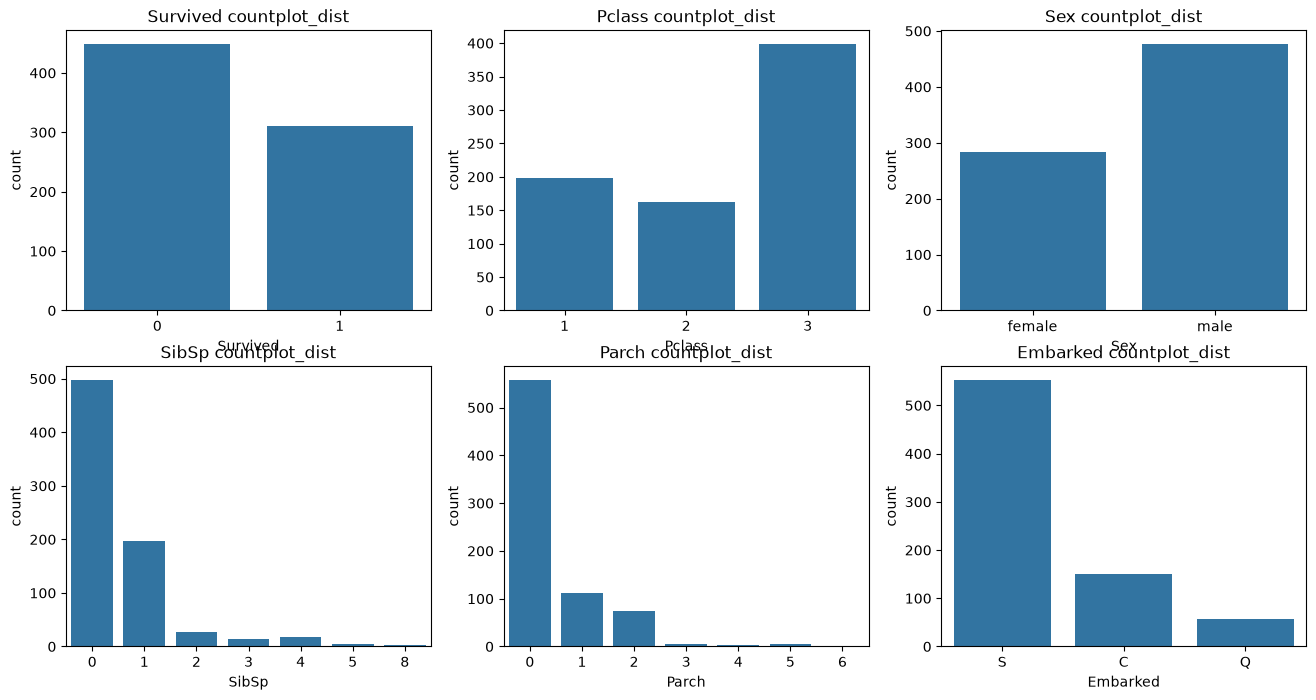

In [29]:
# cat_col = df.select_dtypes('category').columns
cat_cols =['Survived', 'Pclass', 'Sex','SibSp', 'Parch', 'Embarked']
plt.figure(figsize=(16, 8))

for i , col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col , data = df)
    plt.title(f'{col} countplot_dist')



<function matplotlib.pyplot.show(close=None, block=None)>

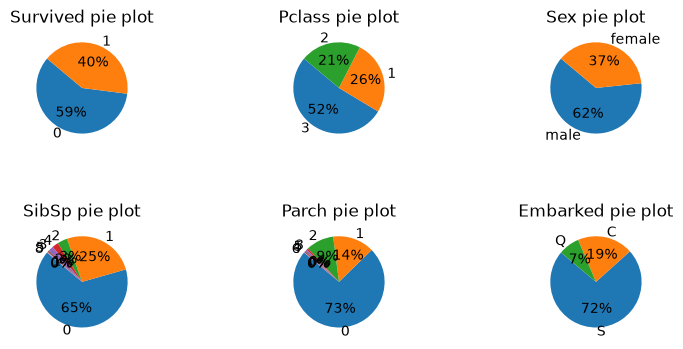

In [30]:
cat_cols
plt.figure(figsize = (9, 4))

for i , col in enumerate(cat_cols) :
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    catergories = unique.index
    plt.pie(count, labels = catergories, startangle= 140, autopct='%1.1d%%')
    plt.title(f'{col} pie plot')

plt.subplots_adjust(hspace= 0.7, wspace= 0.4)
plt.show


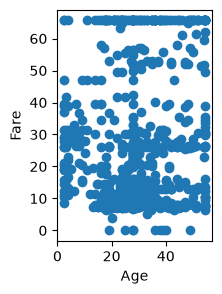

In [31]:
plt.figure(figsize= (2, 3))
plt.scatter(df['Age'],df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

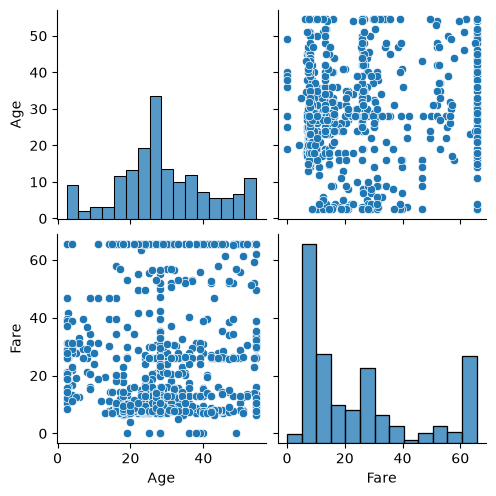

In [32]:
sns.pairplot(df)

In [33]:
corr_1 = df.corr(numeric_only= True)
corr_1

,Age,Fare
Age,1.000000,0.148527
Fare,0.148527,1.000000


<Axes: xlabel='Survived', ylabel='Fare'>

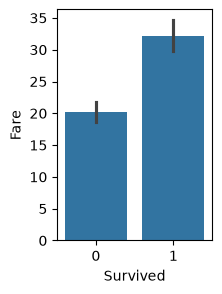

In [34]:
plt.figure(figsize= (2,3))
sns.barplot(x = 'Survived', y = 'Fare', data = df)

# Spliting


In [35]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,65.6563,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [68]:
x1 = df.drop('Survived', axis = 1)
y = df[['Survived']]

In [69]:
num_col

['Age', 'Fare']

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x1[num_col])
x1[num_col] = scaler.transform(x1[num_col])
# x[num_col] = scaler.fit_transform(x[num_col])

In [76]:
x1[num_col]

,Age,Fare
0,0.375000,0.110424
1,0.682692,1.000000
2,0.451923,0.120704
3,0.625000,0.808757
4,0.625000,0.122608
...,...,...
755,0.701923,0.443598
756,0.317308,0.456925
757,0.490385,0.357163
758,0.451923,0.456925


In [77]:
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.375000,1,0,0.110424,S
1,1,female,0.682692,1,0,1.000000,C
2,3,female,0.451923,0,0,0.120704,S
3,1,female,0.625000,1,0,0.808757,S
4,3,male,0.625000,0,0,0.122608,S


In [75]:
x1.reset_index(drop = True, inplace = True)

In [79]:
str_cols = ['Sex', 'Embarked']

In [80]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols = str_cols, drop_invariant = True)
x1 = encoder.fit_transform(x1)

In [81]:
x1.head()

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.375000,1,0,0.110424,1,0,0
1,1,0,1,0.682692,1,0,1.000000,0,1,0
2,3,0,1,0.451923,0,0,0.120704,1,0,0
3,1,0,1,0.625000,1,0,0.808757,1,0,0
4,3,1,0,0.625000,0,0,0.122608,1,0,0
